In [1]:
## DO THIS CODE AT THE START OF ANY NEW WORKBOOK

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
# I now need to bring in all 20 CSVs. Instead of pulling them in one at a time, I am going to use a loop

# Now I need an empty lists to hold all of the DataFrames once I have read them in
season_list = []
advanced_list = []

for season in range(2015,2025):
    season_files = "Season Data " + str(season) + ".csv" # creating the name of the season data
    advanced_files = "Advanced Data " + str(season) + ".csv" # creating the name of the advanced data
    season_stats = pd.read_csv(season_files) # brining in CSV based off of name set above
    advanced_stats = pd.read_csv(advanced_files) # brining in CSV based off of name set above
    season_stats["Season"] = season # adds a season column
    advanced_stats["Season"] = season # adds a season column
    season_list.append(season_stats) # appending the CSV files into the appropriate list
    advanced_list.append(advanced_stats) # appending the CSV files into the appropriate list
    season_data = pd.concat(season_list, ignore_index = True) # combining all 10 season DFs into 1
    advanced_data = pd.concat(advanced_list, ignore_index = True) # combining all 10 advanced DFs into 1

In [4]:
# Now that the data has been brought in and I have a Season Stats and Advanced Stats CSVs, I need to clean them
# Some teams have "*" because they were playoff teams
# The Advanced CSVs had blank columns in them
# Each CSV has a League Average column

season_data["Team"] = season_data["Team"].str.replace("*","", regex = False) # removing * and replacing with blanks
advanced_data["Team"] = advanced_data["Team"].str.replace("*","", regex = False) # removing * and replacing with blanks

# I had no clue how to remove blank columns. Noticed they all shared Unnanmed in the title
# I had to learn how to remove these through outside help
season_data = season_data.loc[:, ~season_data.columns.str.contains("Unnamed")]
advanced_data = advanced_data.loc[:, ~advanced_data.columns.str.contains("Unnamed")]

# For all of the rows that were the League Average, the RK column populates NaN
# So I can remove all rows that have NaN in RK and get rid of these
season_data = season_data[season_data["Rk"].notna()]
advanced_data = advanced_data[advanced_data["Rk"].notna()]

In [5]:
# Now that I have two DataFrames (Season Data and Advanced Data) I can merge the two
# I will merge them based on Team and Season
combined_data = pd.merge(season_data, advanced_data, on = ["Team","Season"])

# BIG ISSUE FOUND!!!! In the Advanced Data, Basketball Reference tracks both offense and defense
# eFG%, TOV%, FT/FGA all are calculoated for both offense and defense. I need to change the column names
combined_data = combined_data.rename(columns = {"eFG%":"Off_eFG%", "eFG%.1":"Def_eFG%", "TOV%":"Off_TOV%","TOV%.1":"Def_TOV%","FT/FGA":"Off_FT_Rate","FT/FGA.1":"Def_FT_Rate"})

In [6]:
# Additionally, some of this data I do not need for this analysis (Rk, Arena, Attend, Attend/G)
# I am going to remove them since I do not need them
combined_data = combined_data.drop(columns = ["Rk_x","Rk_y","Arena","Attend.","Attend./G"])

In [26]:
# Now I need to add/calculate some additional metrics not found in the data that I want part of my analysis
# I will add Win%, Assist to TO Ratio, and 3PA Ratio
combined_data["Win Percentage"] = combined_data["W"] / (combined_data["W"] + combined_data["L"])
combined_data["ATR"] = combined_data["AST"] / combined_data["TOV"]
combined_data["3PA Ratio"] = combined_data["3PA"] / combined_data["FGA"]

In [ ]:
# RESEARCH QUESTION 1: How Have Advanced/Efficiency Stats Evolved During the Analytics Boom Era

# I want to examine if the overall performance of advanced metrics have increased over this era
# The question is that if there is a true emphasis on these types of stats, will there be an increase in advanced metrics performance?
# I am creating a new DataFrame of all advanced metrics that I believe are the most impactful and influencial
# I will need to get the average for each stat by Season in order to plot the overall trend

Text(0.5, 0.98, 'Research Question 1: Evolution of Advanced NBA Metrics (2015 - 2024)')

Text(0.5, 1.0, 'Evolution of Efficiency Metrics in the NBA (2015 - 2024)')

Text(0.5, 0, 'Season')

Text(0, 0.5, 'League Average')

Text(0.5, 1.0, 'Evolution of Performance Metrics in the NBA (2015 - 2024)')

Text(0.5, 0, 'Season')

Text(0, 0.5, 'Points per 100 Possessions')

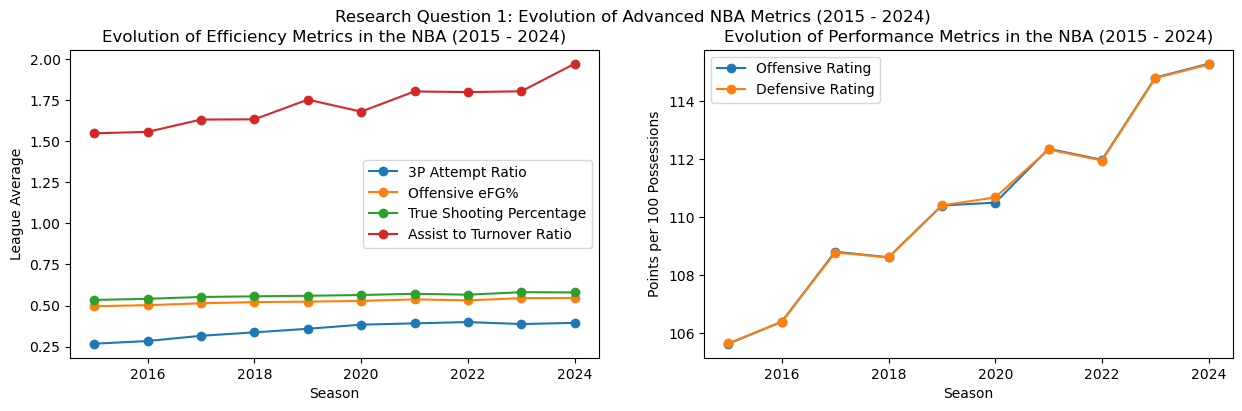

In [27]:
metric_trends = combined_data.groupby("Season")[["3PA Ratio","Off_eFG%","TS%","ORtg","DRtg","ATR"]].mean().reset_index()

fig, axes = plt.subplots(1,2, figsize = (15,4))

fig.suptitle("Research Question 1: Evolution of Advanced NBA Metrics (2015 - 2024)")

# Efficiency Metrics Chart
axes[0].plot(metric_trends["Season"], metric_trends["3PA Ratio"], marker = 'o', label = "3P Attempt Ratio")
axes[0].plot(metric_trends["Season"], metric_trends["Off_eFG%"], marker = 'o', label = "Offensive eFG%")
axes[0].plot(metric_trends["Season"], metric_trends["TS%"], marker = 'o', label = "True Shooting Percentage")
axes[0].plot(metric_trends["Season"], metric_trends["ATR"], marker = 'o', label = "Assist to Turnover Ratio")

axes[0].set_title("Evolution of Efficiency Metrics in the NBA (2015 - 2024)")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("League Average")
axes[0].legend()

# Performance Ratings Chart
axes[1].plot(metric_trends["Season"], metric_trends["ORtg"], marker = 'o', label = "Offensive Rating")
axes[1].plot(metric_trends["Season"], metric_trends["DRtg"], marker = 'o', label = "Defensive Rating")

axes[1].set_title("Evolution of Performance Metrics in the NBA (2015 - 2024)")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Points per 100 Possessions")
axes[1].legend()

In [39]:
# RESEARCH QUESTION 2: Which Team Metrics are most Strongly Associated with Winning

# Q1 showed that the trend of advanced metrics is increasing. Now we examine which metrics contribute to winning
# Unfortunately I want to include all metrics but sizing made that impossible.
# I removed NetRtg as I have seen that before and the relationship is practically perfeclt linear
# I included ORtg and DRtg since those are the stats that make up NetRtg
# I removed Assist to Turnover Ratio because I would rather see shooting metrics such as Off_eFG% and 3PA Ratio (since that is the direction of the game)

In [43]:
# I need to create a new DataFrame containing all of the stats that I want to see
# These will be metrics that I think will have the strongest (could be positive/negative) relationships
correlation_metrics = combined_data[["Win Percentage","ORtg","DRtg","Off_eFG%","3PA Ratio"]]

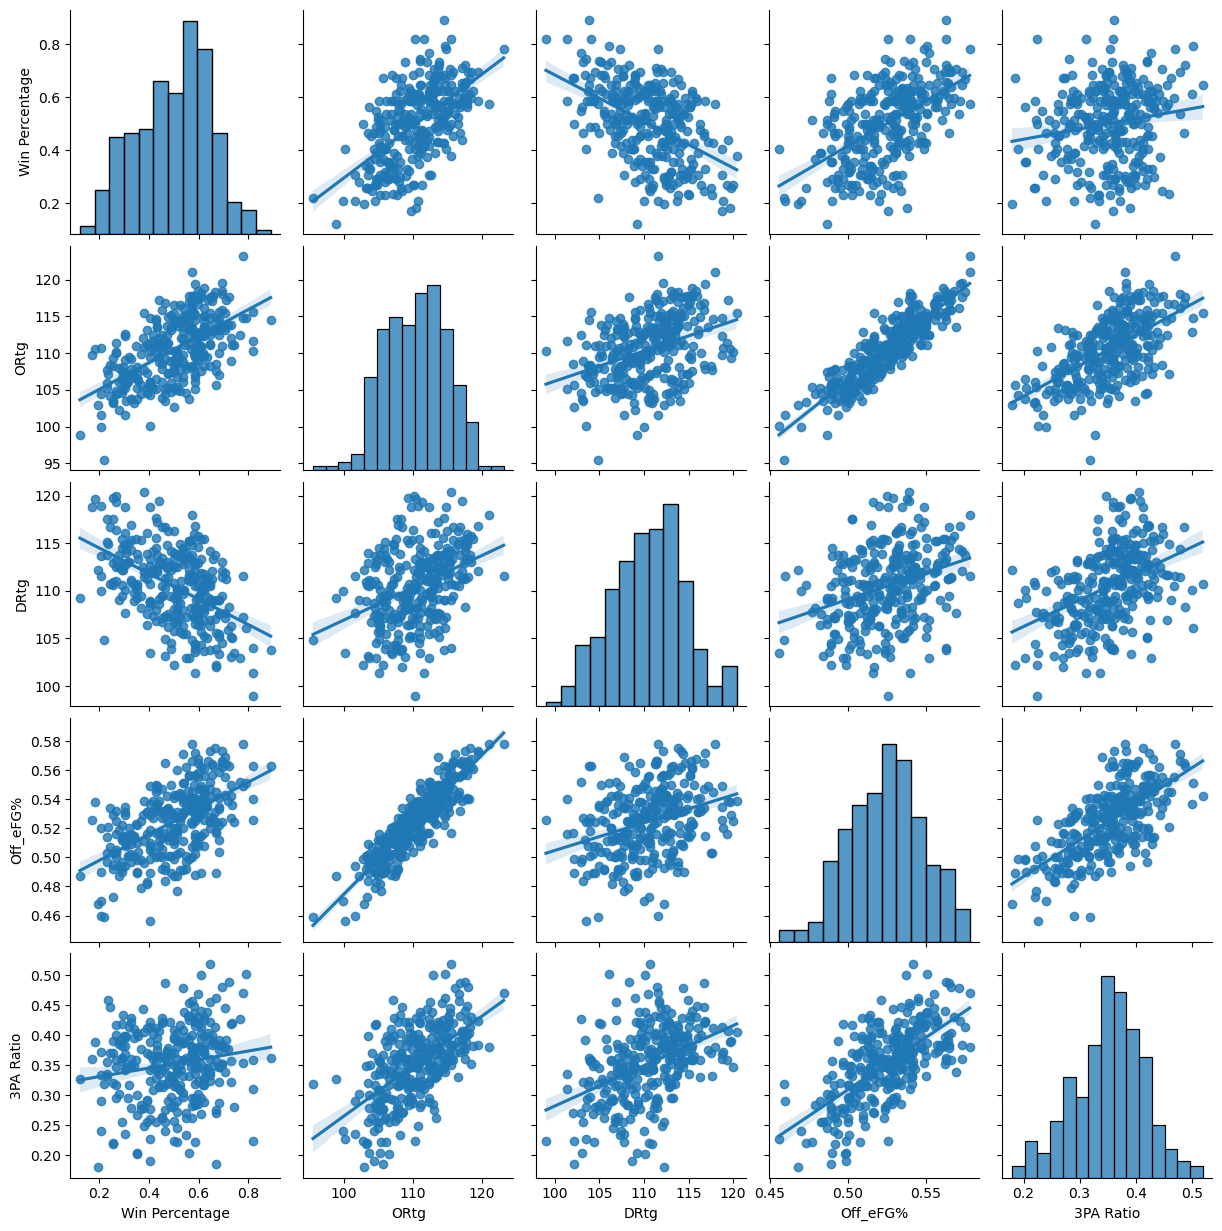

In [41]:
sns.pairplot(correlation_metrics, kind = 'reg')

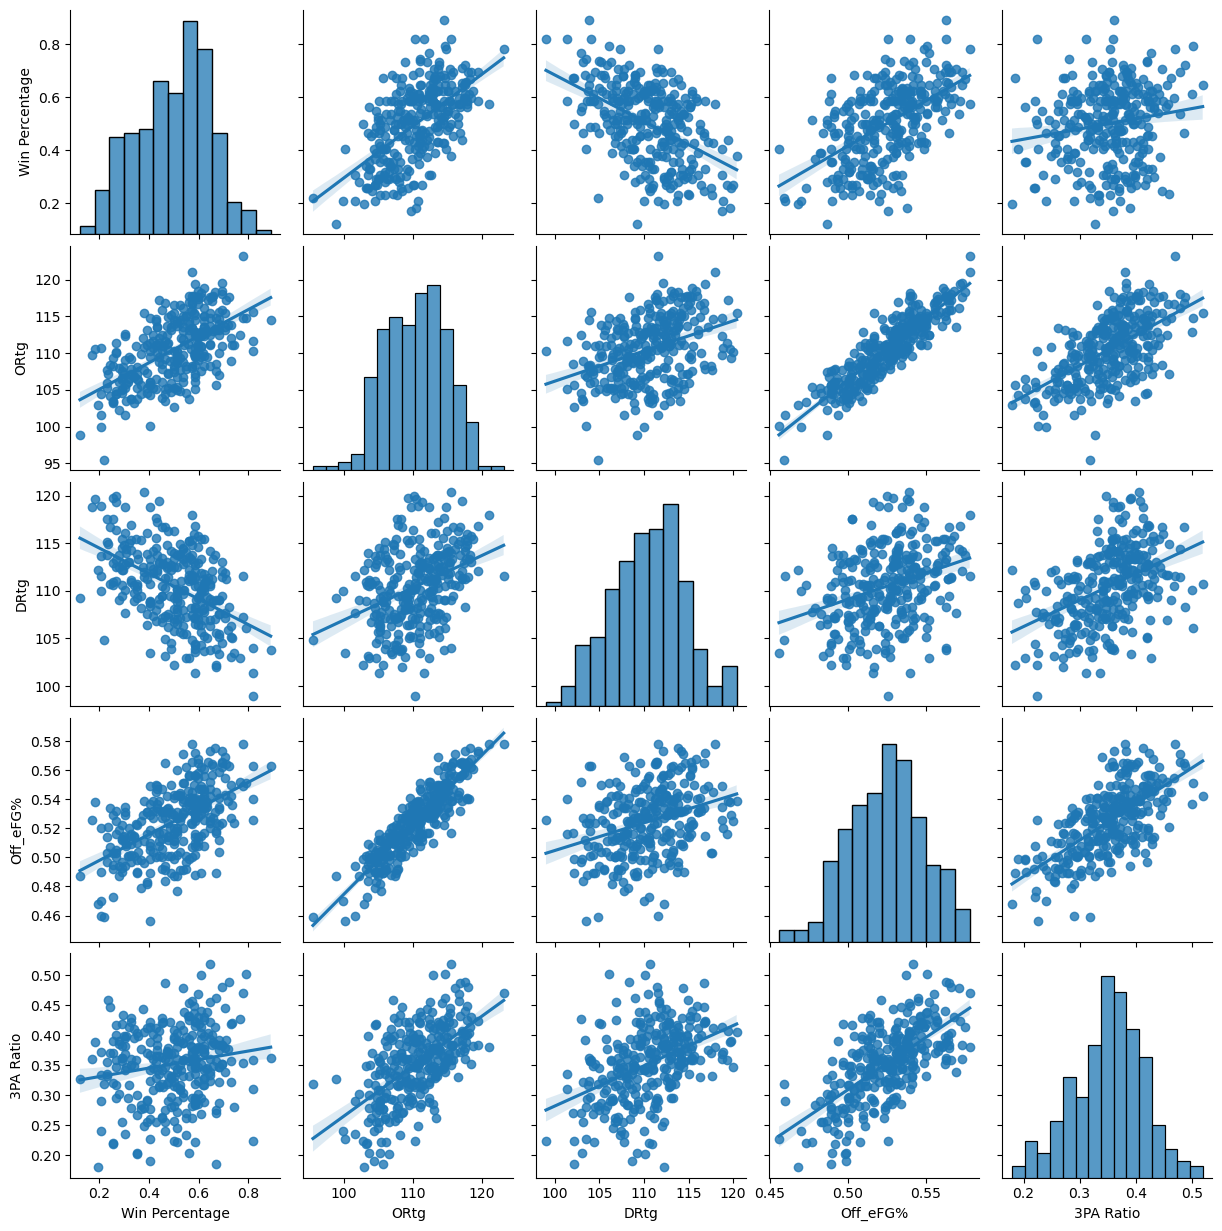

In [42]:
sns.pairplot(correlation_metrics, kind = 'reg').savefig("What Impacts Winning.png")

Text(0.5, 0.98, 'Research Question 2: Which Team Metrics are most Strongly Associated with Winning (2015 - 2024)')

<Axes: >

Text(0.5, 1.0, 'Correlation Between Advanced Metrics')

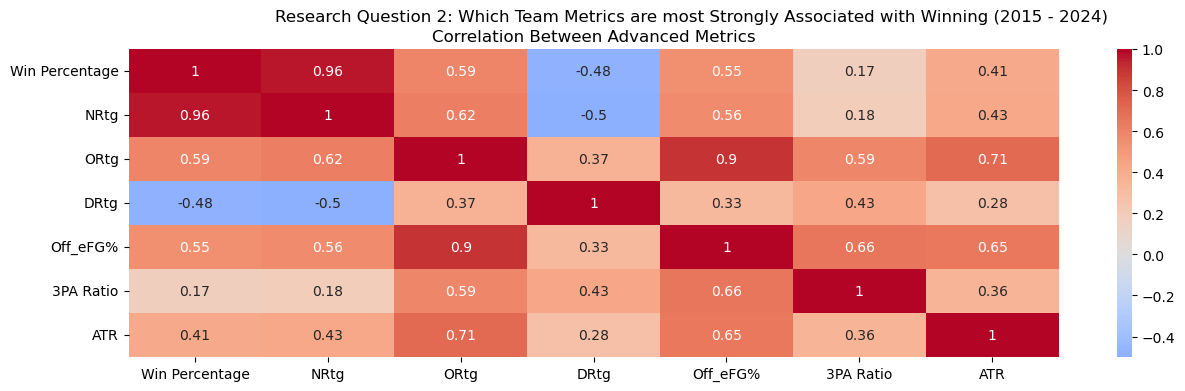

In [34]:
# Additionally, I am going to make a Heatmap to show the correlation numerically
# I need to first make a correlation matrix showing the relationship between all chosen variables

matrix = correlation_metrics.corr()

fig, ax = plt.subplots(figsize = (15,4))

fig.suptitle("Research Question 2: Which Team Metrics are most Strongly Associated with Winning (2015 - 2024)")

sns.heatmap(matrix, annot = True, cmap = "coolwarm", center = 0, ax = ax)

ax.set_title("Correlation Between Advanced Metrics")

In [13]:
# RESEARCH QUESTION 3: Which Advanced/Efficiency Metric Best Relates to Winning Percentage

# Q2 and other labs/activities in the class have helped me see relationships between 2 variables
# I want to take the analysis a step further and see that how all metrics interact with each other
# Like other sports, basketball has plenty of metrics that influence each other (eFG% to ORtg)
# To do this, I will build a very simple linear model using a plethora of advanced metrics
# I want to highlight aspects such as off/def efficiency, shot selection, security of the ball, and others
# This will provide additional inisght beyond how impactful say NRtg is to Winning Percentage

In [14]:
# DISCLOSURE: I was unfamilair with how to create this. I needed to use resources outside our class materials

import statsmodels.api as sm # library that lets me build and analyze a linear regression model

X = combined_data[["ORtg","DRtg","Off_eFG%","ATR","3PA Ratio"]] # outlining the metrics that will impact the model
y = combined_data["Win Percentage"] # the output of the model. What I am trying to predict

X = sm.add_constant(X) # adds a constant so we have a base value

model = sm.OLS(y,X).fit() # the type of model. A Least Squares Regression

print(model.summary()) # a summary of the model. I am most interested in Coefficients and the R^2 value

                            OLS Regression Results                            
Dep. Variable:         Win Percentage   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     803.3
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          4.58e-169
Time:                        18:55:23   Log-Likelihood:                 552.82
No. Observations:                 300   AIC:                            -1094.
Df Residuals:                     294   BIC:                            -1071.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4242      0.090      4.695      0.0

Text(0.5, 0.98, 'Research Question 3: Which Advanced/Efficiency Metric Best Relates to Winning Percentage (2015 - 2024)')

Text(0.5, 1.0, 'Win Percentage Predictions vs Actual Performance')

Text(0.5, 0, 'Predicted Win Percentage')

Text(0, 0.5, 'Actual Win Percentage')

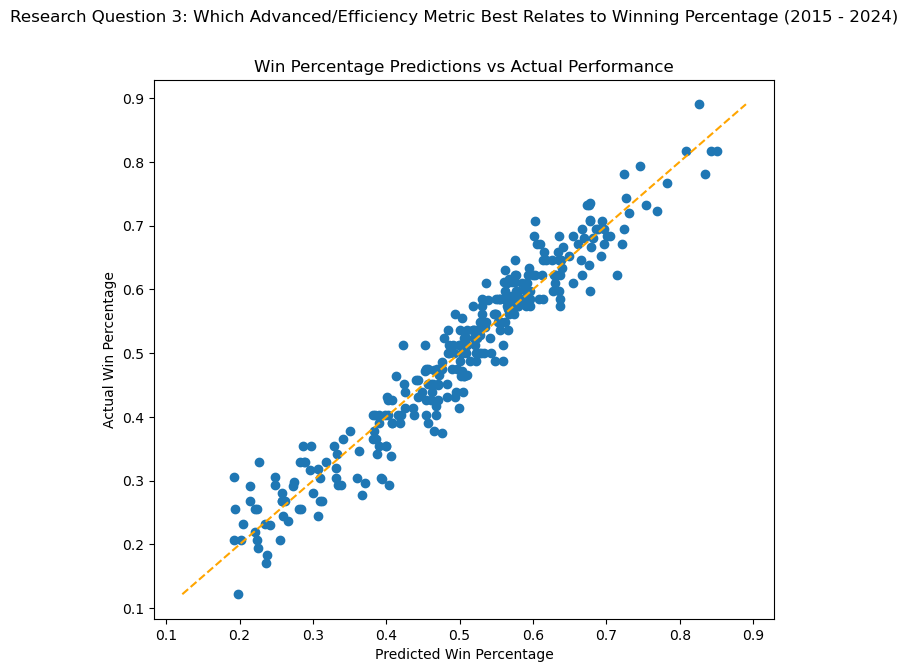

In [35]:
wins = model.predict(X)

fig, ax = plt.subplots(figsize = (8,7)) # creating a figure for the plot to go

fig.suptitle("Research Question 3: Which Advanced/Efficiency Metric Best Relates to Winning Percentage (2015 - 2024)")

ax.scatter(wins, y) # creating the scatterplot of predicted win % vs actual win%
ax.plot([y.min(), y.max()], [y.min(), y.max()], color = "orange", linestyle = "--") # adds the regression line
ax.set_title("Win Percentage Predictions vs Actual Performance") # sets a title
ax.set_xlabel("Predicted Win Percentage") # sets an x axis label
ax.set_ylabel("Actual Win Percentage") # sets a y axis label

In [16]:
# RESEARCH QUESTION 4: What Advanced Metrics Define the Elite NBA Teams

# Now I want to see how Elite teams compare to the rest of the league
# This is important to analyze since we want to see if the emphasis on advanced metrics really does matter
# I will be setting 53 wins as the standard. That is a 65% Win %
# I want to see if an emphasis on analytics is clear by elite teams vs others or if everyone has gotten better
# If all teams share simialr performance, there could be an additional input on to why teams perform better

In [17]:
# I need to add a column to my Combined Data and write in some criteria that will label each team as Elite or not
combined_data["Team Type"] = "Non-Elite" # set all teams as non-elite. Make it easier to then write the Elite code
combined_data["Team Type"][combined_data["Win Percentage"] >= 0.65] = "Elite" # label all teams >65% as Elite

elite_stats = combined_data.groupby("Team Type")[["ORtg","DRtg","Off_eFG%","ATR","3PA Ratio"]].mean().reset_index()

C:\Users\willi\AppData\Local\Temp\ipykernel_4608\1085855710.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  combined_data["Team Type"][combined_data["Win Percentage"] >= 0.65] = "Elite" # label all teams >65% as Elite
C:\Users\willi\AppD

Text(0.5, 0.98, 'Research Question 4: What Advanced Metrics Define the Elite NBA Teams (2015 - 2024)')

<Axes: xlabel='Team Type'>

Text(0.5, 1.0, 'Elite v Not Elite NBA Teams - Offensive and Defensive Rating')

Text(0.5, 0, 'Team Type')

Text(0, 0.5, 'Points per 100 Possessions')

...

Text(0.5, 0, 'Team Type')

Text(0, 0.5, 'Average Performance')

[Text(0, 0, '0.54'), Text(0, 0, '0.52')]

[Text(0, 0, '1.83'), Text(0, 0, '1.70')]

[Text(0, 0, '0.37'), Text(0, 0, '0.35')]

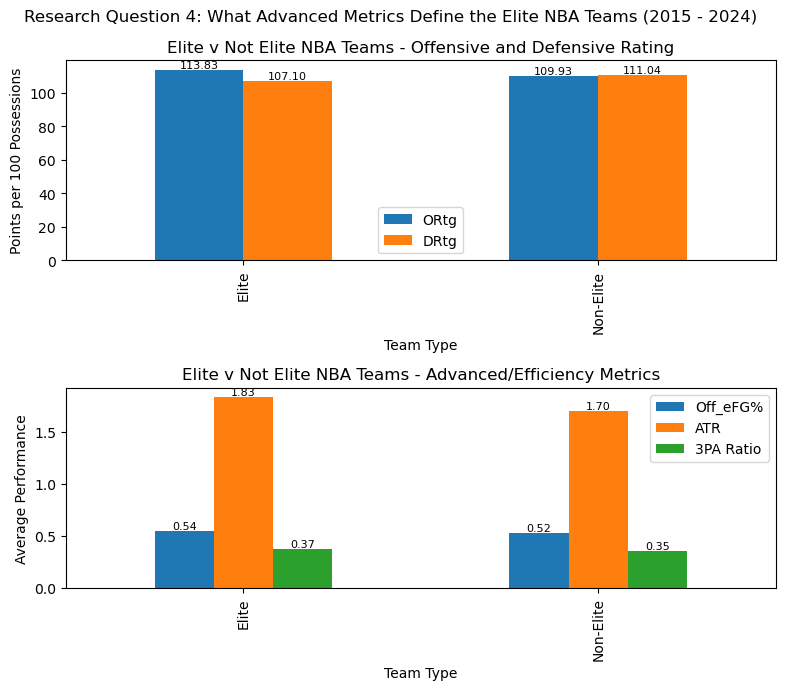

In [36]:
# Now I can create the Bar graph that will show grouped performance of these metrics
fig, axes = plt.subplots(2,1, figsize = (8,7))

fig.suptitle("Research Question 4: What Advanced Metrics Define the Elite NBA Teams (2015 - 2024)")


elite_stats.set_index("Team Type")[["ORtg","DRtg"]].plot( kind = "bar", ax = axes[0])

axes[0].set_title("Elite v Not Elite NBA Teams - Offensive and Defensive Rating")
axes[0].set_xlabel("Team Type")
axes[0].set_ylabel("Points per 100 Possessions")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt = '%.2f', fontsize = 8) # adding data labels

elite_stats.set_index("Team Type")[["Off_eFG%","ATR","3PA Ratio"]].plot( kind = "bar", ax = axes[1])

axes[1].set_title("Elite v Not Elite NBA Teams - Advanced/Efficiency Metrics")
axes[1].set_xlabel("Team Type")
axes[1].set_ylabel("Average Performance")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt = '%.2f', fontsize = 8) # adding data labels

plt.tight_layout()